# Notebook 04: Pump Price Prediction — Modeling

## Introduction

This notebook uses naive models to serve as a baseline for the predictive model for pump price pass through to retail pump stations.

Three naive baselines will be implemented namely:

### Persistence

The basic assumption for commodities are that the prices today will be the price tomorrow (price stickines)

$$Y_{pred}^{t+1}=Y_{t}$$

### Seasonal Naive

Next would be that the price next year will be the same as today

$$Y_{pred} = Y_{t-52}$$

### MOPS-Derived Pricing

Means of Platts Singapore is the benchmark used by the Asian Energy Market for pricing fuel. Based on the weekly transactions in Jurong, the Department of Energy sets pricing with that information plus known firm margins and premiums

$$Y_{pred}=\alpha + \beta \cdot (MOPS_{t-1}\cdot E_{t-1}^{nom})$$

In [16]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error
from scipy.stats import randint, uniform
import warnings
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [17]:
df = pd.read_parquet('data/final/features_engineered.parquet')
with open('./data/final/feature_sets.json') as f:
    feature_sets = json.load(f)

In [18]:
TARGET_COLS = ['DIESEL', 'DIESEL PLUS', 'KEROSENE', 'RON 91', 'RON 95', 'RON 97', 'RON 100']
EXCISE_MAP  = {
    'diesel': 'excise_diesel', 'diesel_plus': 'excise_diesel',
}

DIESEL_FEATURES = [
    'brent_mean_lag1',
    'dubai_close_lag1','usd_php_mean_lag1','cpi_value_lag1',
    'crack_spread_lag1','mops_vol_12w_lag1',
    'brent_vol_12w_lag1',
    'mops_chg_pos_lag2','mops_chg_neg_lag2',
    'mops_gasoil_mean_lag2','mops_gasoil_mean_lag3','mops_gasoil_mean_lag4',
    'brent_mean_lag2','brent_mean_lag3','brent_mean_lag4',
    'dubai_close_lag2','dubai_close_lag3','dubai_close_lag4',
    'excise_diesel'
]
DIESEL_FEATURES = [f for f in DIESEL_FEATURES if f in df.columns]

In [19]:
print('Loaded:', df.shape)
print('Date range:', df.index.min().date(), '→', df.index.max().date())
print('Products available in feature_sets:', list(feature_sets.keys()))

Loaded: (397, 103)
Date range: 2018-01-30 → 2026-04-28
Products available in feature_sets: ['DIESEL', 'DIESEL PLUS', 'KEROSENE', 'RON 91', 'RON 95', 'RON 97', 'RON 100']


In [20]:
# Last 52 weeks = test set (~1 year)
# Chronological split — no shuffle, no leakage
PRODUCT    = 'DIESEL'      # change to loop over all products later
TEST_WEEKS = 52

features  = feature_sets[PRODUCT]
features  = [f for f in features if f in df.columns]   # guard against missing cols

X = df[features]
y = df[PRODUCT]

split_idx       = len(df) - TEST_WEEKS
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Product: {PRODUCT.upper()}')
print(f'Train: {len(X_train)} rows  ({X_train.index.min().date()} → {X_train.index.max().date()})')
print(f'Test:  {len(X_test)} rows  ({X_test.index.min().date()} → {X_test.index.max().date()})')
print(f'Features: {len(features)}')
print(f'\nTest set target stats:')
print(f'  Mean ₱{y_test.mean():.2f}  Min ₱{y_test.min():.2f}  Max ₱{y_test.max():.2f}')
print(f'  Train max ₱{y_train.max():.2f} — test max exceeds train by '
      f'{(y_test.max()/y_train.max()-1)*100:.1f}%')

Product: DIESEL
Train: 345 rows  (2018-01-30 → 2025-04-15)
Test:  52 rows  (2025-04-22 → 2026-04-28)
Features: 29

Test set target stats:
  Mean ₱64.77  Min ₱49.71  Max ₱141.61
  Train max ₱86.20 — test max exceeds train by 64.3%


In [21]:
# ── Diagnose NaNs before doing anything ──────────────────────────────────────
nan_cols = X_train.columns[X_train.isna().any()].tolist()
print(f'Columns with NaN in X_train: {len(nan_cols)}')
if nan_cols:
    print(pd.DataFrame({
        'train_nulls': X_train[nan_cols].isna().sum(),
        'test_nulls':  X_test[nan_cols].isna().sum()
    }))

# ── Impute remaining NaNs (forward-fill then backward-fill, then median fallback)
# ffill/bfill handles structural gaps from lag construction at boundaries
# median fallback handles any isolated NaN that ffill can't reach
X_train = X_train.ffill().bfill()
X_test  = X_test.ffill().bfill()

# Median fallback for any column that is STILL NaN (e.g. entirely null column)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)   # use train median on test — no leakage

print(f'\nNaN remaining after imputation — train: {X_train.isna().sum().sum()}  '
      f'test: {X_test.isna().sum().sum()}')

# ── Identify crude lag columns for PCA compression ───────────────────────────
crude_prefixes = ('mops_gasoil_mean_lag', 'brent_mean_lag',
                  'dubai_close_lag',      'mops_in_php_lag')
features       = list(X_train.columns)
crude_idx      = [i for i, f in enumerate(features)
                  if any(f.startswith(p) for p in crude_prefixes)]
other_idx      = [i for i in range(len(features)) if i not in crude_idx]
other_names    = [features[i] for i in other_idx]

print(f'\nCrude lag columns for PCA: {len(crude_idx)}')
print(f'Other features:            {len(other_idx)}')

if len(crude_idx) == 0:
    print('WARNING: No crude lag columns found — check feature names match crude_prefixes')
    print('Sample feature names:', features[:10])

# ── Fit scaler on training data ONLY ─────────────────────────────────────────
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

# ── Fit PCA on training crude block ONLY, retain 95% variance ────────────────
if len(crude_idx) >= 2:
    pca_probe   = PCA().fit(X_train_s[:, crude_idx])
    cumvar      = np.cumsum(pca_probe.explained_variance_ratio_)
    n_comp      = int(np.argmax(cumvar >= 0.95) + 1)

    pca         = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_s[:, crude_idx])
    X_test_pca  = pca.transform(X_test_s[:, crude_idx])

    X_train_f   = np.hstack([X_train_s[:, other_idx], X_train_pca])
    X_test_f    = np.hstack([X_test_s[:,  other_idx], X_test_pca])
    feature_names = other_names + [f'crude_PC{i+1}' for i in range(n_comp)]

    print(f'PCA: {len(crude_idx)} crude cols → {n_comp} components '
          f'({cumvar[n_comp-1]*100:.1f}% variance retained)')
else:
    # No crude block found — skip PCA, use all features as-is
    X_train_f, X_test_f = X_train_s, X_test_s
    feature_names = features
    print('PCA skipped — using all scaled features directly')

print(f'\nFinal matrix shape — train: {X_train_f.shape}  test: {X_test_f.shape}')
print(f'NaN check — train: {np.isnan(X_train_f).sum()}  test: {np.isnan(X_test_f).sum()}')

assert np.isnan(X_train_f).sum() == 0, "STOP: NaNs still present in X_train_f"
assert np.isnan(X_test_f).sum()  == 0, "STOP: NaNs still present in X_test_f"
print('\n✓ No NaNs — safe to proceed to model training')

Columns with NaN in X_train: 2
                    train_nulls  test_nulls
mops_vol_12w_lag1            10           0
brent_vol_12w_lag1           10           0

NaN remaining after imputation — train: 0  test: 0

Crude lag columns for PCA: 13
Other features:            16
PCA: 13 crude cols → 1 components (95.9% variance retained)

Final matrix shape — train: (345, 17)  test: (52, 17)
NaN check — train: 0  test: 0

✓ No NaNs — safe to proceed to model training


In [22]:
# ── Cell 4 — Param spaces (Pipeline-aware keys use estimator__param syntax) ──
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

param_spaces = {
    'Ridge': {
        'estimator__alpha': uniform(0.01, 100)
    },
    'SVR': {
        'estimator__kernel':  ['rbf', 'linear'],
        'estimator__C':       uniform(0.1, 200),
        'estimator__epsilon': uniform(0.01, 2),
        'estimator__gamma':   ['scale', 'auto'],
    },
    'RFR': {
        'estimator__n_estimators':      randint(100, 600),
        'estimator__max_depth':         [None, 5, 10, 20],
        'estimator__min_samples_split': randint(2, 20),
        'estimator__min_samples_leaf':  randint(1, 10),
        'estimator__bootstrap':         [True, False],
    }
}

n_iter = {'Ridge': 50, 'SVR': 300, 'RFR': 600}

# Minimum training rows needed before the first fold is valid
# 5 splits × 17-week test = need at least ~100 rows in train
print(f'X_train_f rows: {len(X_train_f)}')
n_splits  = 5
test_size = 17
min_train = len(X_train_f) - (n_splits * test_size)
print(f'Smallest CV training fold will have ~{min_train} rows')
if min_train < 20:
    print('WARNING: reduce n_splits or test_size — folds are too small')

tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

X_train_f rows: 345
Smallest CV training fold will have ~260 rows


In [23]:
# ── Helper functions — run this before the training cell ─────────────────────
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

def mase(y_true, y_pred, y_train):
    """
    Mean Absolute Scaled Error.
    Denominator = in-sample one-step naive MAE (persistence on training set).
    MASE < 1.0 means the model beats naive persistence.
    """
    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive = mean_absolute_error(y_train[1:], y_train[:-1])
    return mae_model / mae_naive if mae_naive > 0 else np.nan

def evaluate(name, y_true, y_pred, y_train_vals):
    """Return a metrics dict for one model/baseline."""
    return dict(
        name = name,
        R2   = r2_score(y_true, y_pred),
        MAE  = mean_absolute_error(y_true, y_pred),
        MAPE = mean_absolute_percentage_error(y_true, y_pred) * 100,
        MASE = mase(y_true, y_pred, y_train_vals)
    )

print('Helper functions defined: mase(), evaluate()')

Helper functions defined: mase(), evaluate()


In [24]:
# ── Cell 5 — Train models with imputation inside the Pipeline ────────────────
results        = []   # reset — will re-add baselines below if needed
best_estimators = {}



# Re-add baselines so the final table is complete
y_persist = y.shift(1).loc[y_test.index].values
y_snaive  = y.shift(52).loc[y_test.index].values
for bname, bp in [('Persistence', y_persist), ('Seasonal Naive', y_snaive)]:
    mask = ~np.isnan(bp)
    results.append(evaluate(bname, y_test[mask].values, bp[mask], y_train.values))
base_models = {
    'Ridge': Ridge(),
    'SVR':   SVR(),
    'RFR':   RandomForestRegressor(random_state=42),
}

for name, model in base_models.items():
    print(f'\nTuning {name}...')

    # Wrap in Pipeline: median imputer → model
    # Imputer re-fits on each CV fold's training slice → no leakage
    pipe = Pipeline([
        ('imputer',   SimpleImputer(strategy='median')),
        ('estimator', model),
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions = param_spaces[name],
        n_iter              = n_iter[name],
        cv                  = tscv,
        scoring             = 'neg_mean_absolute_percentage_error',
        random_state        = 42,
        n_jobs              = -1,
        refit               = True,
        error_score         = 'raise',   # surface real errors immediately
    )

    search.fit(X_train_f, y_train)
    best_estimators[name] = search.best_estimator_

    y_pred = search.best_estimator_.predict(X_test_f)

    metrics = dict(
        name = name,
        R2   = r2_score(y_test, y_pred),
        MAE  = mean_absolute_error(y_test, y_pred),
        MAPE = mean_absolute_percentage_error(y_test, y_pred) * 100,
        MASE = mase(y_test.values, y_pred, y_train.values)
    )
    results.append(metrics)

    # Best params — strip 'estimator__' prefix for readability
    clean_params = {k.replace('estimator__', ''): v
                    for k, v in search.best_params_.items()}
    print(f'  Best params : {clean_params}')
    print(f'  Test MAPE   : {metrics["MAPE"]:.2f}%')
    print(f'  Test MASE   : {metrics["MASE"]:.3f}')
    print(f'  Test R²     : {metrics["R2"]:.4f}')

res_df = pd.DataFrame(results).set_index('name')
print('\n=== RESULTS TABLE ===')
print(res_df.round(4).to_string())


Tuning Ridge...
  Best params : {'alpha': np.float64(2.0684494295802445)}
  Test MAPE   : 4.57%
  Test MASE   : 2.551
  Test R²     : 0.7320

Tuning SVR...
  Best params : {'C': np.float64(19.988278551869033), 'epsilon': np.float64(0.4963443819989082), 'gamma': 'auto', 'kernel': 'linear'}
  Test MAPE   : 4.62%
  Test MASE   : 2.587
  Test R²     : 0.7447

Tuning RFR...
  Best params : {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 6, 'min_samples_split': 19, 'n_estimators': 528}
  Test MAPE   : 5.49%
  Test MASE   : 3.360
  Test R²     : 0.4247

=== RESULTS TABLE ===
                    R2     MAE     MAPE    MASE
name                                           
Persistence     0.6724  4.4042   5.2936  3.0317
Seasonal Naive -0.1390  9.4152  11.9981  6.4812
Ridge           0.7320  3.7052   4.5683  2.5505
SVR             0.7447  3.7583   4.6214  2.5871
RFR             0.4247  4.8810   5.4859  3.3600


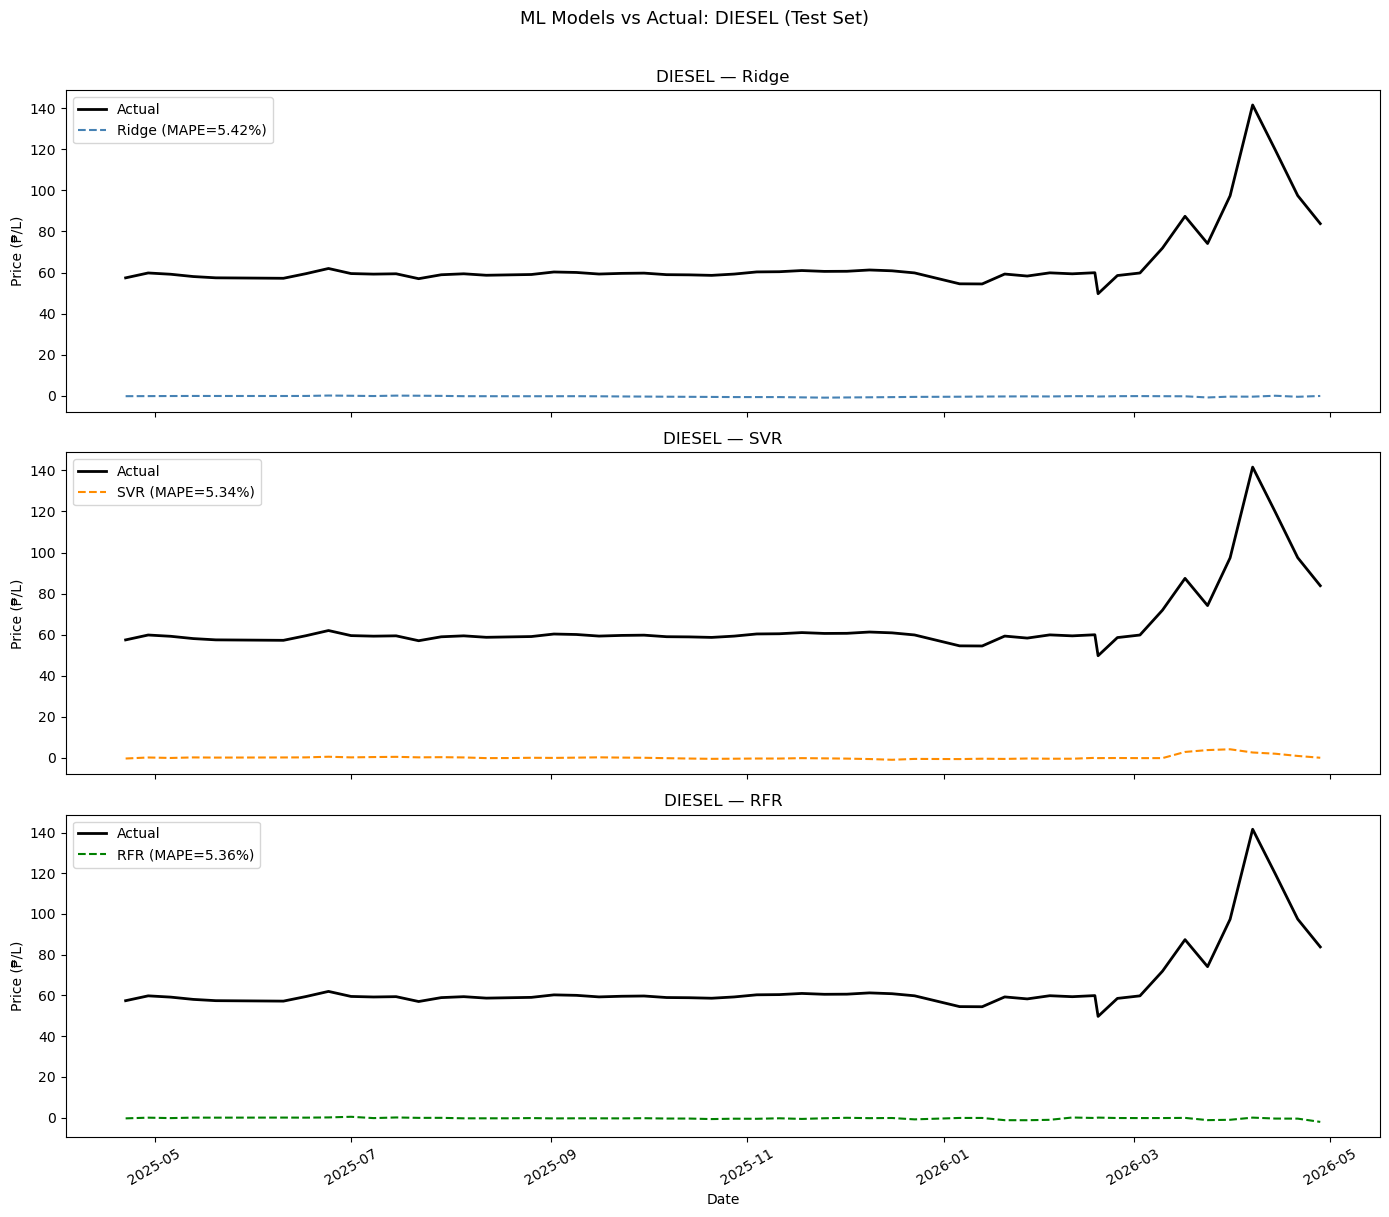

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
colors = {'Ridge': 'steelblue', 'SVR': 'darkorange', 'RFR': 'green'}

for ax, (name, model) in zip(axes, best_estimators.items()):
    y_pred = model.predict(X_test_f)
    ax.plot(y_test.index, y_test.values, 'k-', lw=2, label='Actual')
    ax.plot(y_test.index, y_pred, '--', lw=1.5,
            color=colors[name], label=f'{name} (MAPE={res_df.loc[name,"MAPE"]:.2f}%)')
    ax.set_ylabel('Price (₱/L)')
    ax.legend(loc='upper left')
    ax.set_title(f'{PRODUCT.upper()} — {name}')
    ax.tick_params(axis='x', rotation=30)

axes[-1].set_xlabel('Date')
plt.suptitle(f'ML Models vs Actual: {PRODUCT.upper()} (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig(f'../outputs/04_{PRODUCT}_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# naive baseline: predict the next value to be the same as the last value

# Correct persistence: ŷ_t = y_{t-1} (lag 1 of the test target)
y_pred_persistence = y.shift(1).loc[y_test.index].values



In [27]:
# --- Baseline Evaluation ---
from sklearn.metrics import mean_absolute_error, r2_score

def mase(y_true, y_pred):
    mae_model = mean_absolute_error(y_true, y_pred)
    # naive forecast error = mean of one-step differences in the test period
    mae_naive = mean_absolute_error(y_train.values[1:], y_train.values[:-1])
    return mae_model / mae_naive

baselines = {
    'Persistence':      y_pred_persistence,
}

print('%-20s  %-10s  %-10s  %-10s  %-10s' % ('Baseline', 'R2', 'MAE (₱)', 'MAPE (%)', 'MASE'))
print('-' * 65)
for name, y_pred in baselines.items():
    mask = ~np.isnan(y_pred)
    r2   = r2_score(y_test[mask], y_pred[mask])
    mae  = mean_absolute_error(y_test[mask], y_pred[mask])
    mape = mean_absolute_percentage_error(y_test[mask], y_pred[mask]) * 100
    ms   = mase(y_test[mask].values, y_pred[mask])  # no y_train argument
    print('%-20s  %-10.4f  %-10.4f  %-10.4f  %-10.4f' % (name, r2, mae, mape, ms))

print()
print("MASE interpretation: < 1.0 = beats persistence, > 1.0 = worse than persistence")
print("Your ML models MUST beat these numbers to justify their complexity.")

Baseline              R2          MAE (₱)     MAPE (%)    MASE      
-----------------------------------------------------------------
Persistence           0.6724      4.4042      5.2936      3.0317    

MASE interpretation: < 1.0 = beats persistence, > 1.0 = worse than persistence
Your ML models MUST beat these numbers to justify their complexity.


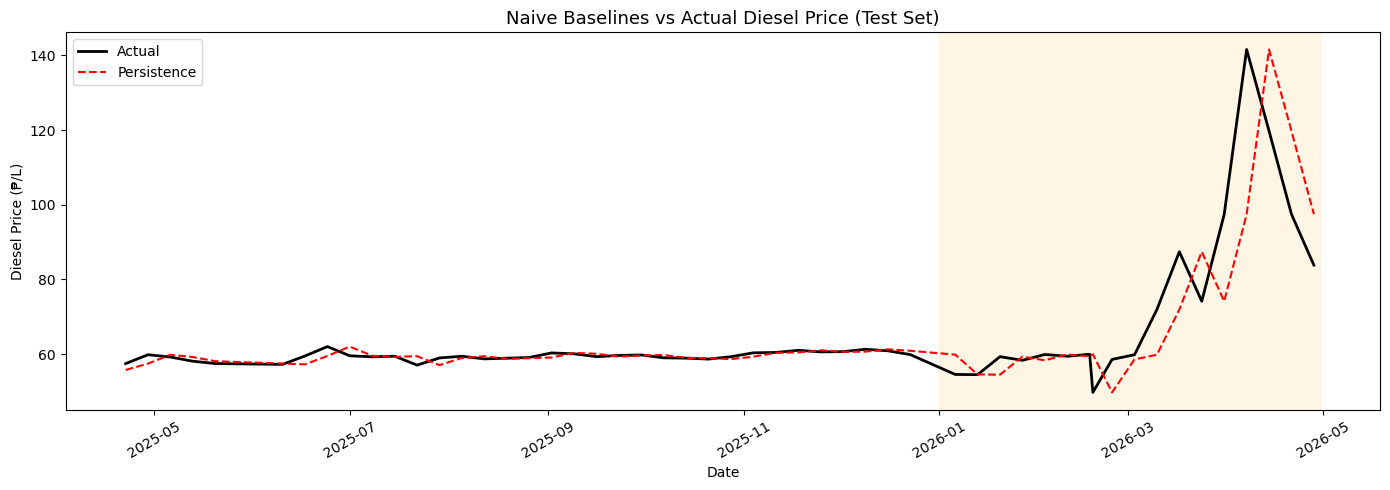

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index, y_test.values,        'k-',  linewidth=2,   label='Actual')
ax.plot(y_test.index, y_pred_persistence,   'r--', linewidth=1.5, label='Persistence')
ax.set_title('Naive Baselines vs Actual Diesel Price (Test Set)', fontsize=13)
ax.set_ylabel('Diesel Price (₱/L)')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=30)
ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-04-30'),
           alpha=0.1, color='orange', label='2026 tariff shock')
plt.tight_layout()
plt.savefig('../outputs/04_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

## Delta Price Prediction

In [35]:
# ── 1. Create the Delta Target ───────────────────────────────────────────────
df['DIESEL_DIFF'] = df['DIESEL'].diff()
y_abs = df['DIESEL']

TEST_WEEKS = 52

# Guard against missing columns and handle the NaN created by .diff()
X = df[DIESEL_FEATURES].ffill().bfill().iloc[1:]
y_diff = df['DIESEL_DIFF'].iloc[1:]
y_abs = y_abs.iloc[1:]

# ── 2. Train/Test Split ──────────────────────────────────────────────────────
# Subtract 1 from split_idx because we dropped the first row
split_idx = len(X) - TEST_WEEKS

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# Target variables for training (Deltas)
y_train_diff, y_test_diff = y_diff.iloc[:split_idx], y_diff.iloc[split_idx:]

# Target variables for final evaluation (Absolute Prices)
y_train_abs, y_test_abs = y_abs.iloc[:split_idx], y_abs.iloc[split_idx:]

print(f'Training set: {len(X_train)} samples ({X_train.index.min().date()} → {X_train.index.max().date()})')
print(f'Test set:     {len(X_test)} samples ({X_test.index.min().date()} → {X_test.index.max().date()})')

Training set: 344 samples (2018-02-06 → 2025-04-15)
Test set:     52 samples (2025-04-22 → 2026-04-28)


In [36]:
# ── 3. Scaling & PCA ─────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Identify crude lag block
crude_prefixes = ['mops_gasoil_mean_lag','brent_mean_lag','dubai_close_lag','mops_in_php_lag']
crude_idx  = [i for i,f in enumerate(DIESEL_FEATURES) if any(f.startswith(p) for p in crude_prefixes)]
other_idx  = [i for i in range(len(DIESEL_FEATURES)) if i not in crude_idx]
other_names = [DIESEL_FEATURES[i] for i in other_idx]

# Fit PCA on training crude block only
pca          = PCA(n_components=2)
X_train_pca  = pca.fit_transform(X_train_s[:, crude_idx])
X_test_pca   = pca.transform(X_test_s[:, crude_idx])

X_train_f = np.hstack([X_train_s[:, other_idx], X_train_pca])
X_test_f  = np.hstack([X_test_s[:,  other_idx], X_test_pca])

print('Crude lag columns compressed by PCA: %d → 2' % len(crude_idx))
print('Final feature matrix shape: train=%s  test=%s' % (X_train_f.shape, X_test_f.shape))

Crude lag columns compressed by PCA: 11 → 2
Final feature matrix shape: train=(344, 10)  test=(52, 10)


In [37]:
# ── 4. Helper Functions & Baselines ──────────────────────────────────────────
def mase(y_true, y_pred, y_train_actuals):
    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive = mean_absolute_error(y_train_actuals[1:], y_train_actuals[:-1])
    return mae_model / mae_naive if mae_naive > 0 else np.nan

def evaluate(name, y_true, y_pred, y_train_actuals):
    return dict(
        name = name,
        R2   = r2_score(y_true, y_pred),
        MAE  = mean_absolute_error(y_true, y_pred),
        MAPE = mean_absolute_percentage_error(y_true, y_pred) * 100,
        MASE = mase(y_true, y_pred, y_train_actuals)
    )

# Persistence Baseline (Absolute Prices)
y_pred_persistence = df['DIESEL'].shift(1).loc[y_test_abs.index].values

results = []
mask = ~np.isnan(y_pred_persistence)
results.append(evaluate('Persistence', y_test_abs.values[mask], y_pred_persistence[mask], y_train_abs.values))

In [38]:
# ── 5. Train Models on Deltas ────────────────────────────────────────────────
param_spaces = {
    'Ridge': {'estimator__alpha': uniform(0.01, 100)},
    'SVR':   {'estimator__kernel': ['rbf', 'linear'], 'estimator__C': uniform(0.1, 200), 'estimator__epsilon': uniform(0.01, 2), 'estimator__gamma': ['scale', 'auto']},
    'RFR':   {'estimator__n_estimators': randint(100, 600), 'estimator__max_depth': [None, 5, 10, 20], 'estimator__min_samples_split': randint(2, 20), 'estimator__min_samples_leaf': randint(1, 10), 'estimator__bootstrap': [True, False]}
}

n_iter = {'Ridge': 50, 'SVR': 300, 'RFR': 300}
tscv = TimeSeriesSplit(n_splits=5, test_size=17)
best_estimators = {}
predictions_abs_dict = {}

base_models = {'Ridge': Ridge(), 'SVR': SVR(), 'RFR': RandomForestRegressor(random_state=42)}

for name, model in base_models.items():
    print(f'Tuning {name} on Price Deltas...')
    
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('estimator', model)])
    
    search = RandomizedSearchCV(
        pipe, param_distributions=param_spaces[name], n_iter=n_iter[name],
        cv=tscv, scoring='neg_mean_absolute_error', # MAE is required for Deltas
        random_state=42, n_jobs=-1, refit=True
    )

    # Fit on DELTAS
    search.fit(X_train_f, y_train_diff)
    best_estimators[name] = search.best_estimator_

    # Predict DELTAS
    y_pred_diff = search.best_estimator_.predict(X_test_f)

    # Reconstruct ABSOLUTE PRICE (Previous Week Actual + Predicted Delta)
    previous_week_actual = df['DIESEL'].shift(1).loc[y_test_abs.index].values
    y_pred_abs = previous_week_actual + y_pred_diff
    predictions_abs_dict[name] = y_pred_abs

    # Evaluate on ABSOLUTE PRICE
    metrics = evaluate(name, y_test_abs.values, y_pred_abs, y_train_abs.values)
    results.append(metrics)

res_df = pd.DataFrame(results).set_index('name')
print('\n=== RESULTS TABLE (Absolute Prices) ===')
print(res_df.round(4).to_string())

Tuning Ridge on Price Deltas...
Tuning SVR on Price Deltas...
Tuning RFR on Price Deltas...

=== RESULTS TABLE (Absolute Prices) ===
                 R2     MAE    MAPE    MASE
name                                       
Persistence  0.6724  4.4042  5.2936  3.0288
Ridge        0.6703  4.4847  5.4191  3.0841
SVR          0.6889  4.3947  5.3374  3.0222
RFR          0.6754  4.4310  5.3633  3.0472


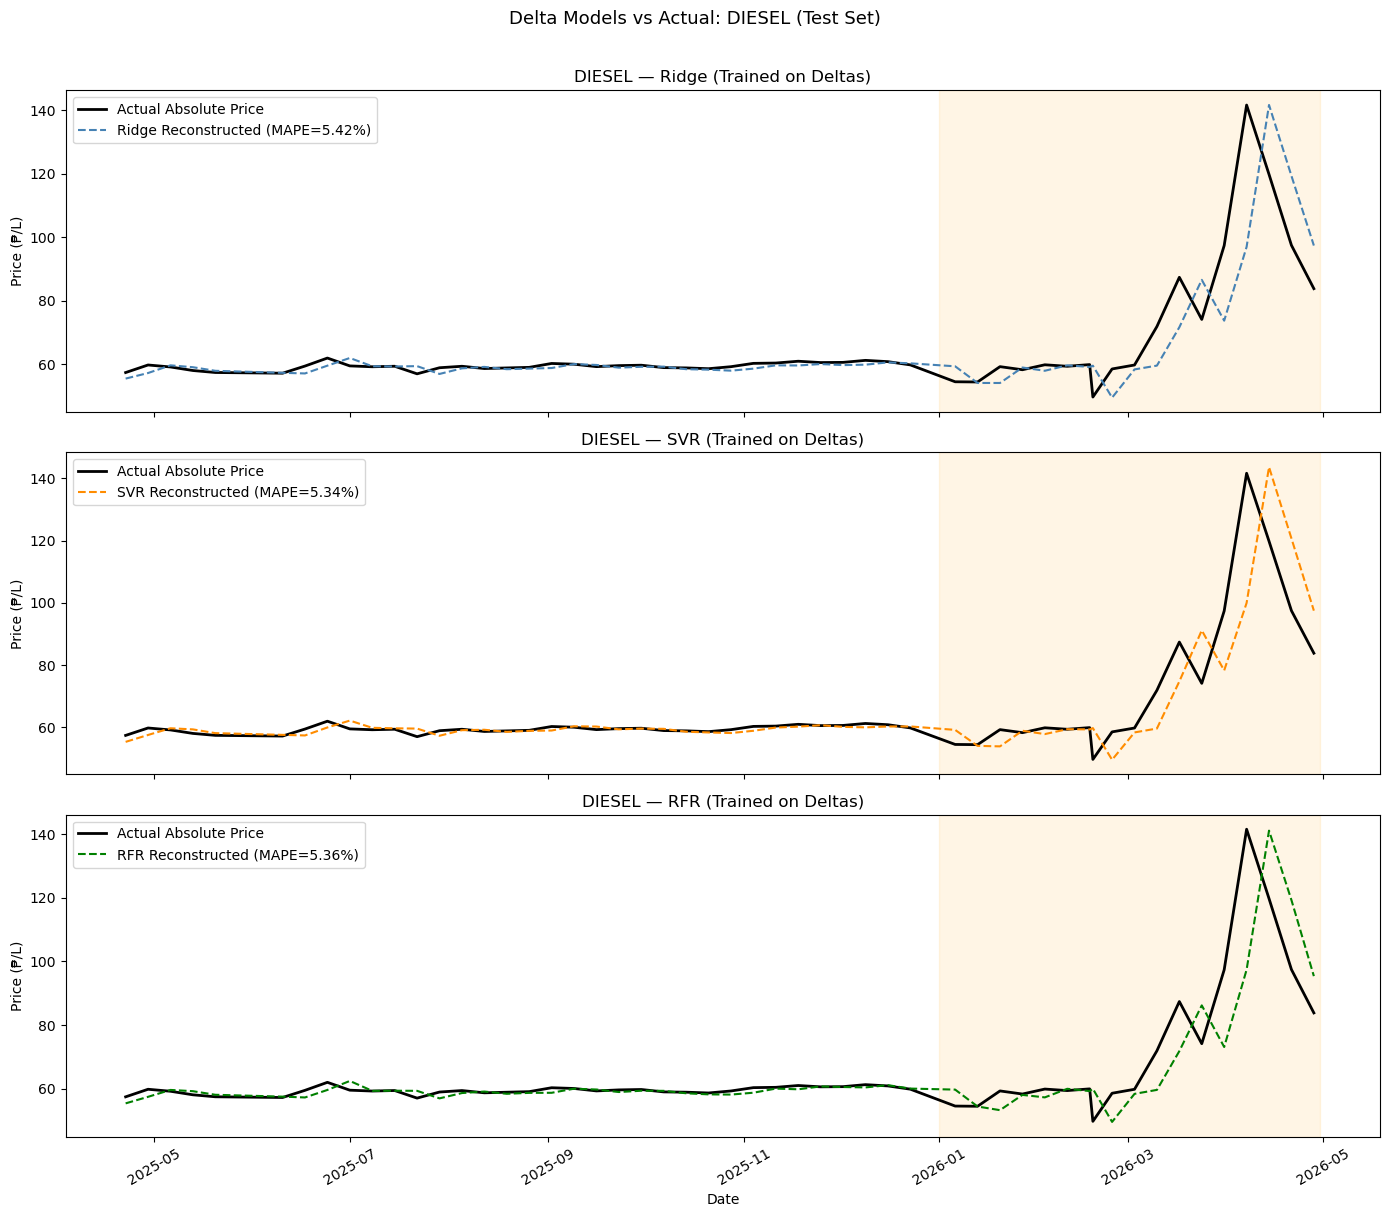

In [39]:
# ── 6. Visualizing the Fix ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
colors = {'Ridge': 'steelblue', 'SVR': 'darkorange', 'RFR': 'green'}

for ax, name in zip(axes, best_estimators.keys()):
    y_pred_abs = predictions_abs_dict[name]
    
    ax.plot(y_test_abs.index, y_test_abs.values, 'k-', lw=2, label='Actual Absolute Price')
    ax.plot(y_test_abs.index, y_pred_abs, '--', lw=1.5,
            color=colors[name], label=f'{name} Reconstructed (MAPE={res_df.loc[name,"MAPE"]:.2f}%)')
    ax.set_ylabel('Price (₱/L)')
    ax.legend(loc='upper left')
    ax.set_title(f'{PRODUCT.upper()} — {name} (Trained on Deltas)')
    ax.tick_params(axis='x', rotation=30)
    
    # Optional: highlight the tariff shock period if relevant
    ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-04-30'), alpha=0.1, color='orange')

axes[-1].set_xlabel('Date')
plt.suptitle(f'Delta Models vs Actual: {PRODUCT.upper()} (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()